**Importing Necessory Libraries**

In [ ]:
!pip install pandas scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Mounting with Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/DS_H_Features Face_Parts/DS_H_Features RightFace(VS).csv'
df = pd.read_csv(file_path)

In [ ]:
df.head()

,image_name,0,1,2,3,4,5,6,7,8,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,DownSyndromeStatus
0,RightFace(VS)_down_592.jpg,0.192292,0.000000,0.103312,0.383887,1.345437,0.076873,0.020891,0.005374,0.002904,...,0.000000,0.740852,0.448979,0.013887,0.000000,0.000000,0.300967,0.192066,0.022414,1
1,RightFace(VS)_down_543.jpg,0.091428,0.052229,0.000000,1.268431,1.224808,0.000000,0.146404,0.248955,0.022652,...,0.073760,0.490185,1.209282,0.036449,0.001502,0.085802,0.000000,0.099623,0.000000,1
2,RightFace(VS)_down_588.jpg,0.010770,0.000000,0.238297,1.968874,1.906611,0.000000,0.209259,0.021979,0.000000,...,0.059615,0.157986,0.285250,0.000000,0.000000,0.021820,0.033598,0.047221,0.026689,1
3,RightFace(VS)_down_545.jpg,0.000000,0.007145,0.000000,1.063041,1.327807,0.014484,0.258002,0.111609,0.011045,...,0.455190,0.360631,0.337726,0.505134,0.000000,0.009444,0.192844,0.119599,0.000000,1
4,RightFace(VS)_down_601.jpg,0.008039,0.072414,0.128351,2.306531,0.961968,0.000000,0.112873,0.017603,0.000000,...,0.077875,0.243047,1.259417,0.000000,0.000000,0.397326,0.698101,0.037283,0.034153,1


In [ ]:
#checking for null values
df.isnull().sum()

,0
image_name,0
0,0
1,0
2,0
3,0
...,...
2044,0
2045,0
2046,0
2047,0


In [ ]:
#null value count
df.isnull().sum().sum()

0

In [ ]:
#Dropping the target coloumn (DownSyndromeStatus) and 'image_name' column as it's not relevant for prediction
X=df.drop(['DownSyndromeStatus','image_name'],axis=1)
y=df['DownSyndromeStatus']

In [ ]:
#Spliting the data with 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
#Initializing the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

#Fitting the model on the training data
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#Prediction on the test set
y_pred = rf_model.predict(X_test)

#Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

#Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

#Classification report
class_report = classification_report(y_test, y_pred)
print('Classification Report:')
print(class_report)

Accuracy: 0.76
Confusion Matrix:
[[208  84]
 [ 56 246]]
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.71      0.75       292
           1       0.75      0.81      0.78       302

    accuracy                           0.76       594
   macro avg       0.77      0.76      0.76       594
weighted avg       0.77      0.76      0.76       594



**Confusion Matrix**

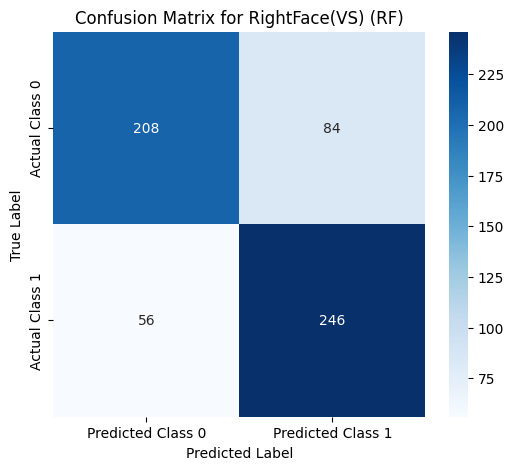

In [ ]:
#Creating heatmap for confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Class 0', 'Predicted Class 1'],
            yticklabels=['Actual Class 0', 'Actual Class 1'])

#giving labels, title, and displaying the plot
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for RightFace(VS) (RF)')
plt.show()

**Area Under the Curve Score**

In [ ]:
#Getting predicted probabilities for the positive class
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

#Calculating False Positive Rate, True Positive Rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

#Calculating the AUC score
auc_score = roc_auc_score(y_test, y_pred_prob)
print(f'AUC Score: {auc_score:.2f}')

AUC Score: 0.84


**ROC (Receiver Operating Characteristic) Curve**

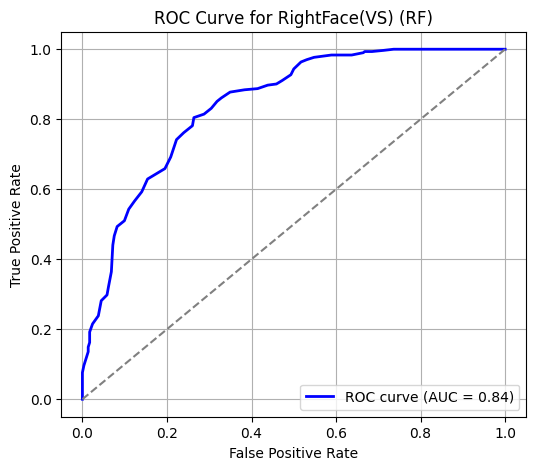

In [ ]:
#Plotting the ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

#Adding labels, title, and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for RightFace(VS) (RF)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()